Trabalho em Grupo — Análise de Dados
Parte 2 — Limpeza e Tratamento dos Dados

Linguagem: Python

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [65]:
# Carrega o dataset
df = pd.read_csv("dataset.csv")

df.head()

,customerid,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,1,58.0,100000.0,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,2,44.0,60000.0,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
2,3,33.0,120000.0,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no
3,4,47.0,20000.0,1506,married,"blue-collar,unknown",no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no
4,5,33.0,0.0,1,single,"unknown,unknown",no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no


In [66]:
# Verifica se existem valores nulos
df.isnull().values.any()

np.True_

In [67]:
# Quantidade de valores nulos em cada variável
df.isnull().sum()

,0
customerid,0
age,20
salary,26
balance,0
marital,0
jobedu,0
targeted,0
default,0
housing,0
loan,0


In [68]:
# Removendo a coluna ID
df.drop(["customerid"], axis=1, inplace=True)

Separarando jobedu

In [69]:
# Add uma coluna para receber os valores de job
df.insert(loc=5, column='job', value='')

In [70]:
# Add uma coluna para receber os valores de edu
df.insert(loc=6, column='edu', value='')

In [71]:
# Dividindo a coluna jobedu
df[['job', 'edu']] = df['jobedu'].str.split(',', expand=True)

# Drop da coluna jobedu
df.drop(["jobedu"], axis=1, inplace=True)

df.head()

,age,salary,balance,marital,job,edu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,58.0,100000.0,2143,married,management,tertiary,yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,44.0,60000.0,29,single,technician,secondary,yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
2,33.0,120000.0,2,married,entrepreneur,secondary,yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no
3,47.0,20000.0,1506,married,blue-collar,unknown,no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no
4,33.0,0.0,1,single,unknown,unknown,no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no


Tratamento de age

In [72]:
# Verifica quais variáveis possuem valores ausentes
df.isna().any()

,0
age,True
salary,True
balance,False
marital,False
job,False
edu,False
targeted,False
default,False
housing,False
loan,False


In [73]:
# Valores ausentes da variável age
df.age.isnull().sum()

np.int64(20)

In [74]:
# Percentual de valores ausentes da variável age
df.age.isnull().mean() * 100

np.float64(0.0442370219636814)

Histograma da idade

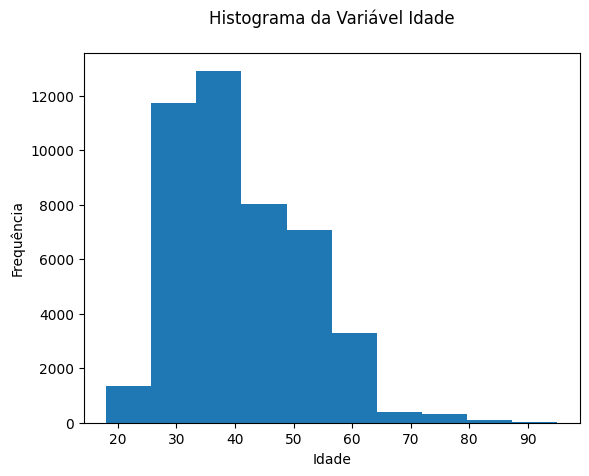

In [75]:
df.age.plot(kind="hist")

plt.title("Histograma da Variável Idade\n")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

Boxplot da idade

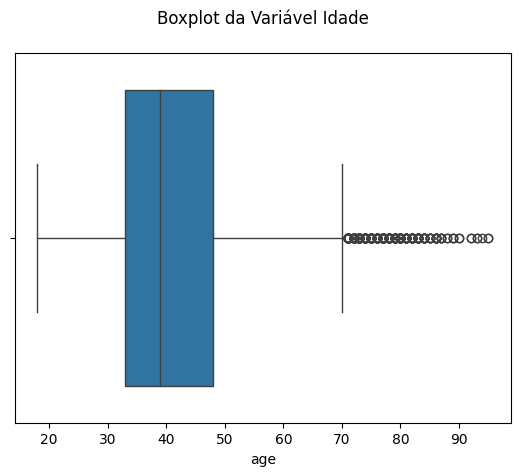

In [76]:
sns.boxplot(x=df.age)

plt.title("Boxplot da Variável Idade\n")
plt.show()

Media, Moda e Mediana

In [77]:
# Média da idade
df.age.mean()

np.float64(40.93565090394105)

In [78]:
# Mediana da idade
df.age.median()

39.0

In [79]:
# Moda da idade
df.age.mode()

,age
0,32.0


Preencher idade com a moda

In [80]:
# Preenchendo os valores ausentes com a moda
df.age.fillna(32, inplace=True)

# Agora convertemos para int
df.age = df.age.astype("int")

df.age.dtypes

dtype('int64')

In [81]:
# Média
df.age.mean()

np.float64(40.93169803808808)

In [82]:
# Mediana
df.age.median()

39.0

In [83]:
# Valores ausentes da variável age
df.age.isnull().sum()

np.int64(0)

In [84]:
# Percentual de valores ausentes
df.age.isnull().mean() * 100

np.float64(0.0)

Tratamento da variável MONTH

In [85]:
# Valores ausentes da variável month
df.month.isnull().sum()

np.int64(50)

In [86]:
# Percentual de valores ausentes
df.month.isnull().mean() * 100

np.float64(0.11059255490920351)

In [87]:
# Tipo da variável
df.month.dtypes

dtype('O')

In [88]:
# Categorias da variável
df.month.value_counts()

,count
month,
"may, 2017",13747
"jul, 2017",6888
"aug, 2017",6240
"jun, 2017",5335
"nov, 2017",3968
"apr, 2017",2931
"feb, 2017",2646
"jan, 2017",1402
"oct, 2017",738


Moda de MONTH

In [89]:
# Moda
df.month.mode()

,month
0,"may, 2017"


In [90]:
# Imputação com a moda
df.month.fillna("may, 2017", inplace=True)

In [91]:
# Valores ausentes na variável
df.month.isnull().sum()

np.int64(0)

In [92]:
# Percentual de valores ausentes
df.month.isnull().mean() * 100

np.float64(0.0)

Tratamento da variável SALARY

In [93]:
# Quantidade de valores ausentes em salary
df.salary.isnull().sum()

np.int64(26)

In [94]:
# Percentual de valores ausentes em salary
df.salary.isnull().mean() * 100

np.float64(0.05750812855278583)

Converter salary para float

In [95]:
# Tipo da variável
df.salary.dtypes

dtype('float64')

In [96]:
# Convertemos para o tipo float
df.salary = df.salary.astype("float")

df.salary.dtypes

dtype('float64')

Histograma de SALARY

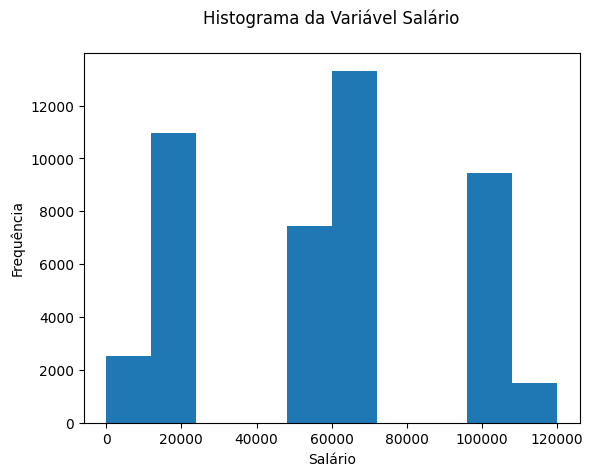

In [97]:
# Histograma do salário
df.salary.plot(kind="hist")

plt.title("Histograma da Variável Salário\n")
plt.xlabel("Salário")
plt.ylabel("Frequência")
plt.show()

Boxplot de SALARY

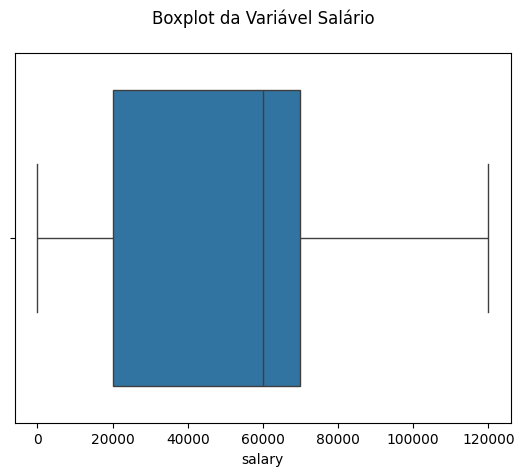

In [98]:
# Boxplot do salário
sns.boxplot(x=df.salary)

plt.title("Boxplot da Variável Salário\n")
plt.show()

Média, mediana e moda do salário

In [99]:
# Média do salário
df.salary.mean()

np.float64(57008.65331415293)

In [100]:
# Mediana do salário
df.salary.median()

60000.0

In [101]:
# Moda do salário
df.salary.mode()

,salary
0,20000.0


Imputar a mediana nos salários ausentes

In [102]:
# Calculando a mediana do salário
mediana_salary = df.salary.median()

mediana_salary

60000.0

In [103]:
# Preenchendo os valores ausentes com a mediana
df.salary.fillna(mediana_salary, inplace=True)

# Conferindo
df.salary.isnull().sum()

np.int64(0)

Verificar os salários

In [104]:
# Registros para cada salário
df.salary.value_counts()

,count
salary,
20000.0,9725
100000.0,9454
60000.0,9195
50000.0,5167
70000.0,4153
55000.0,2264
120000.0,1486
8000.0,1303
16000.0,1239


In [105]:
# Quantidade de salários iguais a zero
(df.salary == 0).sum()

np.int64(288)

substituir salários 0

In [106]:
# Substituindo os salários iguais a zero pela mediana
df.loc[df.salary == 0, "salary"] = df.salary.median()

In [107]:
# Verificando novamente os salários iguais a zero
(df.salary == 0).sum()

np.int64(0)

Novo histograma do salário

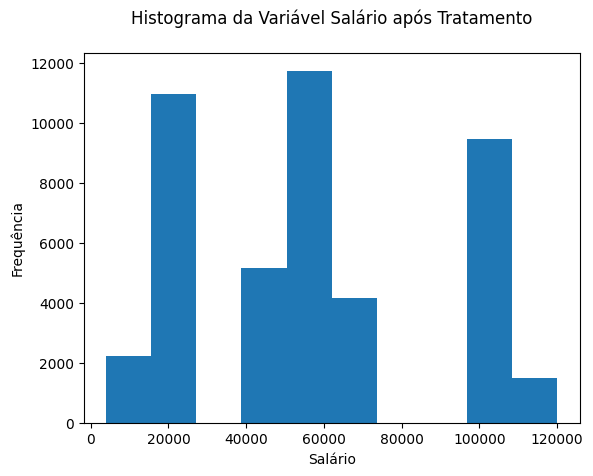

In [108]:
# Histograma após a imputação dos valores zero
df.salary.plot(kind="hist")

plt.title("Histograma da Variável Salário após Tratamento\n")
plt.xlabel("Salário")
plt.ylabel("Frequência")
plt.show()

Novo boxplot

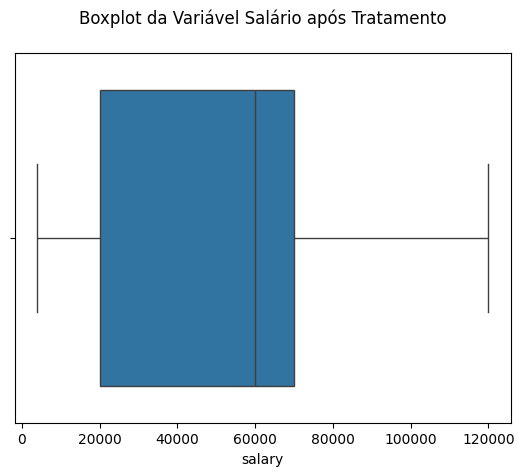

In [109]:
# Boxplot após a imputação
sns.boxplot(x=df.salary)

plt.title("Boxplot da Variável Salário após Tratamento\n")
plt.show()

Tratamento de response

In [110]:
# Valores ausentes de response
df.response.isnull().sum()

np.int64(30)

In [111]:
# Percentual de valores ausentes
df.response.isnull().mean() * 100

np.float64(0.0663555329455221)

In [112]:
# Dropando os registros com response ausente
df.dropna(subset=["response"], inplace=True)

In [113]:
# Verificando novamente
df.response.isnull().sum()

np.int64(0)

Verificar todos os valores NA

In [114]:
# Verifica valores NA
df.isnull().sum()

,0
age,0
salary,0
balance,0
marital,0
job,0
edu,0
targeted,0
default,0
housing,0
loan,0


Tratamento de pdays

In [115]:
# Verificando os valores da variável pdays
df.pdays.value_counts()

,count
pdays,
-1,36930
182,167
92,147
91,126
183,125
...,...
749,1
769,1
587,1


In [116]:
# Substituindo -1 por NaN
df.pdays = df.pdays.replace({-1: np.nan})

In [117]:
# Valores ausentes
df.isnull().sum()

,0
age,0
salary,0
balance,0
marital,0
job,0
edu,0
targeted,0
default,0
housing,0
loan,0


In [118]:
# Percentual de valores ausentes em pdays
df.pdays.isnull().mean() * 100

np.float64(81.73789867422147)

Remover pdays

In [119]:
# Removendo a coluna pdays
df.drop(["pdays"], axis=1, inplace=True)

Verificação final dos valores ausentes

In [120]:
# Valores ausentes
df.isnull().sum()

,0
age,0
salary,0
balance,0
marital,0
job,0
edu,0
targeted,0
default,0
housing,0
loan,0


In [121]:
# Verifica se ainda existem valores nulos
df.isnull().values.any()

np.False_

Conferir o dataset final

In [122]:
# Dimensões do dataset final
df.shape

(45181, 18)

In [123]:
# Primeiras linhas do dataset limpo
df.head()

,age,salary,balance,marital,job,edu,targeted,default,housing,loan,contact,day,month,duration,campaign,previous,poutcome,response
0,58,100000.0,2143,married,management,tertiary,yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,0,unknown,no
1,44,60000.0,29,single,technician,secondary,yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,0,unknown,no
2,33,120000.0,2,married,entrepreneur,secondary,yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,0,unknown,no
3,47,20000.0,1506,married,blue-collar,unknown,no,no,yes,no,unknown,5,"may, 2017",92 sec,1,0,unknown,no
4,33,60000.0,1,single,unknown,unknown,no,no,no,no,unknown,5,"may, 2017",198 sec,1,0,unknown,no


In [124]:
# Informações do dataset final
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45181 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       45181 non-null  int64  
 1   salary    45181 non-null  float64
 2   balance   45181 non-null  int64  
 3   marital   45181 non-null  object 
 4   job       45181 non-null  object 
 5   edu       45181 non-null  object 
 6   targeted  45181 non-null  object 
 7   default   45181 non-null  object 
 8   housing   45181 non-null  object 
 9   loan      45181 non-null  object 
 10  contact   45181 non-null  object 
 11  day       45181 non-null  int64  
 12  month     45181 non-null  object 
 13  duration  45181 non-null  object 
 14  campaign  45181 non-null  int64  
 15  previous  45181 non-null  int64  
 16  poutcome  45181 non-null  object 
 17  response  45181 non-null  object 
dtypes: float64(1), int64(5), object(12)
memory usage: 7.6+ MB


Salvando o Dataset

In [125]:
# Salvando o dataset limpo
df.to_csv("dataset_limpo.csv", index=False)

In [126]:
from google.colab import files

files.download("dataset_limpo.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>